In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Load the single-cell engineered dataset
print("Loading data...")
df = pd.read_csv('./data/engineered_features.csv', index_col='Timestamp', parse_dates=True)

Loading data...


In [3]:
# 2. Create Multi-Step Targets (1 to 6 hours ahead)
# 1 hour = 4 steps, 2 hours = 8 steps... 6 hours = 24 steps.
horizons = {
    '1h_ahead': 4,
    '2h_ahead': 8,
    '3h_ahead': 12,
    '4h_ahead': 16,
    '5h_ahead': 20,
    '6h_ahead': 24
}

target_cols = []
for name, steps in horizons.items():
    col_name = f'target_{name}'
    df[col_name] = df['4G data volume DL'].shift(-steps)
    target_cols.append(col_name)

# Drop rows that don't have enough future data to form all 6 targets
df = df.dropna()

In [4]:
# 3. Define Features and Targets
features = [
    '4G data volume DL', '4G RB utilization', 
    'hour', 'minute', 'day_of_week', 'is_weekend', 
    'vol_lag_1', 'vol_lag_4', 'vol_lag_96'
]
X = df[features]
y = df[target_cols]

In [5]:
# 4. Train/Test Split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} intervals, Testing on {len(X_test)} intervals.")

Training on 6545 intervals, Testing on 1637 intervals.


In [6]:
# 5. Train the Multi-Output Model
print("\nTraining XGBoost Multi-Step Forecaster (1-6 Hours)...")
# We use MultiOutputRegressor to allow XGBoost to predict 6 distinct targets at once
base_xgb = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
multi_model = MultiOutputRegressor(base_xgb)
multi_model.fit(X_train, y_train)


Training XGBoost Multi-Step Forecaster (1-6 Hours)...


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U17](9,)","['4G data volume DL','4G RB utilization','hour',...,'vol_lag_1', 'vol_lag_4','vol_lag_96']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,9
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None


In [7]:
# 6. Predict and Evaluate Each Horizon
y_pred = multi_model.predict(X_test)

print("\n--- Mean Absolute Error (MAE) by Horizon ---")
mae_scores = []
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test[col], y_pred[:, i])
    mae_scores.append(mae)
    print(f"{col.replace('target_', '')}: {mae:.2f} GB")


--- Mean Absolute Error (MAE) by Horizon ---
1h_ahead: 405.66 GB
2h_ahead: 459.89 GB
3h_ahead: 485.44 GB
4h_ahead: 513.24 GB
5h_ahead: 526.04 GB
6h_ahead: 546.72 GB


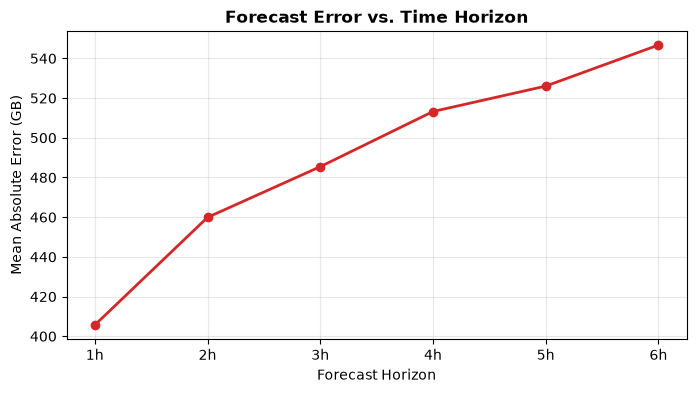

In [8]:
# 7. Plot the degradation of accuracy over time
plt.figure(figsize=(8, 4))
plt.plot(['1h', '2h', '3h', '4h', '5h', '6h'], mae_scores, marker='o', color='tab:red', linewidth=2)
plt.title("Forecast Error vs. Time Horizon", fontweight='bold')
plt.xlabel("Forecast Horizon")
plt.ylabel("Mean Absolute Error (GB)")
plt.grid(True, alpha=0.3)
plt.show()